# Install libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from firthlogist import FirthLogisticRegression
from sklearn.utils.validation import check_X_y

# To resolve the patched_validate issue (Required for Firth in Python 3.10 / newer scikit-learn)

In [2]:
def patched_validate(self, X, y, **kwargs):
    return check_X_y(X, y, **kwargs)
FirthLogisticRegression._validate_data = patched_validate

# Opening cleaned PAROS dataset

In [3]:
CURRENT_DIRECTORY = Path.cwd().resolve()

# Find project root that contains datasets
PROJECT_ROOT = next(
    p for p in [CURRENT_DIRECTORY, *CURRENT_DIRECTORY.parents]
    if (p / "datasets").exists()
)

CLEANED_DATASET_PATH = PROJECT_ROOT / "datasets" / "PAROS_Dataset_Cleaned.csv"

if not CLEANED_DATASET_PATH.exists():
    raise FileNotFoundError(f"Cleaned dataset not found: {CLEANED_DATASET_PATH}")

df = pd.read_csv(CLEANED_DATASET_PATH)
print(f"Loaded cleaned PAROS dataset: {df.shape}")
display(df.head(3))

Loaded cleaned PAROS dataset: (2039, 71)


,Patient brought in by,Date of Incident,Location of incident,Location Unknown,Location Type,Location Type Other,Age,Age Modifier,Gender,Race,...,Outcome of patient,Patient status,Date of Discharge or Death,Patient neurological status - Cerebral,Patient neurological status - Overall,Patient neurological status - Unknown,Year,Call_Time,Shock_Time,Time_to_Defib
0,Ems,2014-01-01,238889.0,NaN,Transport Center,Dhoby Ghaut Mrt Level B1,59,Years,Male,Chinese,...,Died In Ed,NaN,NaN,5.0,NaN,NaN,2014,2026-04-06 22:28:12,2026-04-06 22:39:17,11.083333
1,Ems,2014-01-05,272018.0,NaN,Public/Commercial Building,Level 2,66,Years,Male,Chinese,...,Died In Ed,NaN,NaN,5.0,NaN,NaN,2014,2026-04-06 15:00:42,2026-04-06 15:16:49,16.116667
2,Ems,2014-01-07,760105.0,NaN,Street/Highway,Level 1,80,Years,Male,Indian,...,Admitted,Remains In Hospital At 30Th Day Post Arrest,NaN,4.0,4.0,NaN,2014,2026-04-06 12:05:46,2026-04-06 12:14:08,8.366667


In [4]:
print(df.columns.tolist())


['Patient brought in by', 'Date of Incident', 'Location of incident', 'Location Unknown', 'Location Type', 'Location Type Other', 'Age', 'Age Modifier', 'Gender', 'Race', 'Time call received at dispatch center', 'No First Responder dispatched', 'Time First Responder dispatched', 'Time Ambulance dispatched', 'Time First Responder arrived at scene', 'Time Ambulance arrived at scene', 'Time EMS arrived at patient side', 'Time Ambulance arrived at ED', 'Arrest witnessed by', 'Bystander CPR', 'DA-CPR', 'First CPR initiated by', 'Bystander AED applied', 'Resuscitation attempted by EMS/Private ambulance', 'First arrest rhythm', 'Prehospital Defibrillation', 'Time of first shock given', 'Time of first shock Unknown', 'Defibrillation performed by - First Responder', 'Defibrillation performed by - Ambulance Crew', 'Defibrillation performed by - Bystander - Healthcare provider', 'Defibrillation performed by - Bystander - Lay Person', 'Defibrillation performed by - Bystander - Family', 'Other', 'R

# Define Binary Outcome (Survival to 30 Days)


In [5]:
# 1. Combine all possible outcome columns into one searchable string
outcome_cols = ['Outcome of patient', 'Patient status', 'Final status at scene']

# If any of these columns don't exist in your current slice, only use the ones that do
available_cols = [col for col in outcome_cols if col in df.columns]
df['Outcome_String'] = df[available_cols].astype(str).agg(' '.join, axis=1)

# 2. Use the broad Regex to catch all variations of survival
survival_regex = r'Discharged Alive|Remains in hospital at 30th day|Survived to discharge'
df['Survival_Binary'] = df['Outcome_String'].str.contains(survival_regex, case=False, regex=True).astype(int)

# 3. Verify the number (This should hit your ~297 target from the N=2076 cohort)
print(f"Total Survivors: {df['Survival_Binary'].sum()}")

# Optional Diagnostic: See what strings actually exist if it still doesn't work
if df['Survival_Binary'].sum() == 0:
    print("\nDiagnostic - Unique values in outcome column:")
    print(df['Outcome of patient'].unique())

Total Survivors: 349


# Define Primary Predictor (Bystander AED applied)
- We map any variation of 'Yes' or '1' to 1, and everything else to 0

In [6]:
aed_col = 'Bystander AED applied'
df.loc[:, 'AED_Applied_Binary'] = df[aed_col].astype(str).str.contains('Yes|Applied|1', case=False, na=False).astype(int)

# Cleaned DataFrame

In [7]:
model_vars = ['Survival_Binary', 'AED_Applied_Binary', 'Time_to_Defib']
df_clean = df.dropna(subset=model_vars).copy()

In [8]:
def find_best_tau_v3(data, time_col):
    """
    Runs the V3 Grid Search using Firth Regression to prevent crashes,
    but calculates the UNPENALIZED AIC to ensure accurate model comparison.
    """
    results = []
    
    # Grid search between 3 and 12 minutes
    for t in range(3, 13):
        t_before = data[time_col].clip(upper=t)
        t_after = (data[time_col] - t).clip(lower=0)
        
        # EXACT V3 Feature Matrix 
        X = pd.DataFrame({
            'AED': data['AED_Applied_Binary'],
            'Time_Before': t_before,
            'Time_After': t_after,
            'AED_x_Before': data['AED_Applied_Binary'] * t_before,
            'AED_x_After': data['AED_Applied_Binary'] * t_after
        })
        y = data['Survival_Binary']
        
        try:
            # 1. Fit Firth Model (Stable coefficients, handles separation)
            firth_model = FirthLogisticRegression(max_iter=1000)
            firth_model.fit(X, y)
            
            # 2. Get probabilities manually to be 100% safe across library versions
            coefs = np.array(firth_model.coef_).flatten()
            intercept = float(firth_model.intercept_[0]) if isinstance(firth_model.intercept_, (list, np.ndarray)) else float(firth_model.intercept_)
            linear_pred = np.dot(X, coefs) + intercept
            
            # Sigmoid function for probabilities
            p = 1 / (1 + np.exp(-linear_pred))
            p = np.clip(p, 1e-15, 1 - 1e-15) # Prevent log(0)
            
            # 3. Calculate True Unpenalized Log-Likelihood
            unpenalized_ll = np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))
            
            # 4. Calculate Standard AIC
            k = X.shape[1] + 1  # 5 features + 1 intercept
            aic = 2 * k - 2 * unpenalized_ll
            
            results.append({'tau': t, 'AIC': aic})
        except Exception as e:
            continue
            
    res_df = pd.DataFrame(results)
    if res_df.empty:
        return np.nan
    
    # Return the tau with the lowest Unpenalized AIC
    return res_df.loc[res_df['AIC'].idxmin(), 'tau']

# Binning

In [9]:
bin_scenarios = [0, 1, 2, 5] 
labels = ['Continuous', '1-min Bins', '2-min Bins', '5-min Bins']
discovered_taus = []

# Clean copy for loop
df_chart = df_clean.copy() 

print("Running V3 grid search across bin scenarios...\n")

for b, label in zip(bin_scenarios, labels):
    if b == 0:
        # Ground Truth: V3 exact continuous data
        tau = find_best_tau_v3(df_chart, 'Time_to_Defib')
    else:
        # Create mathematically grouped bins (simulating operational data)
        col_name = f'Time_Bin_{b}'
        df_chart[col_name] = np.floor(df_chart['Time_to_Defib'] / b) * b
        
        # Find tau using the newly binned column
        tau = find_best_tau_v3(df_chart, col_name)
    
    discovered_taus.append(tau)
    print(f"Scenario: {label} -> Discovered Threshold: {tau} min")

Running V3 grid search across bin scenarios...

Scenario: Continuous -> Discovered Threshold: 4 min
Scenario: 1-min Bins -> Discovered Threshold: 6 min
Scenario: 2-min Bins -> Discovered Threshold: 6 min
Scenario: 5-min Bins -> Discovered Threshold: 5 min


# Plot

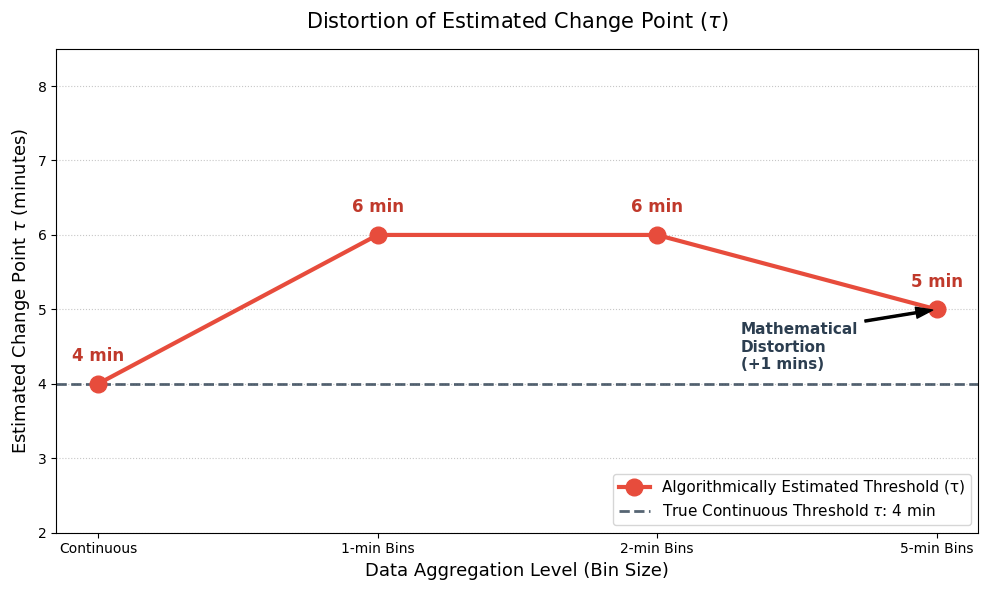

In [10]:
plt.figure(figsize=(10, 6))

# Plot the discovered thresholds
plt.plot(labels, discovered_taus, marker='o', markersize=12, color='#e74c3c', linewidth=3, zorder=3, label='Algorithmically Estimated Threshold (τ)')

# Add text labels for the tau values at each point
for i, tau in enumerate(discovered_taus):
    if not pd.isna(tau):
        # Places the text slightly above the marker
        plt.text(i, tau + 0.25, f"{int(tau)} min", ha='center', va='bottom', 
                 fontsize=12, fontweight='bold', color='#c0392b')

# Draw the True Baseline (from Continuous Data)
plt.axhline(y=4, color='#2c3e50', linestyle='--', alpha=0.8, linewidth=2, zorder=2, label='True Continuous Threshold $\\tau$: 4 min')

# Annotate the 5-min bin drift
drift_val = discovered_taus[-1]
if not pd.isna(drift_val) and drift_val != 4:
    # Proper string formatting for line breaks
    annotation_text = f"Mathematical\nDistortion\n(+{int(drift_val - 4)} mins)"
    
    plt.annotate(annotation_text, 
                 xy=(3, drift_val), 
                 xytext=(2.3, drift_val - 0.8), 
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8), 
                 fontsize=11, fontweight='bold', color='#2c3e50')

# Formatting
plt.title('Distortion of Estimated Change Point ($\\tau$)', fontsize=15, pad=15)
plt.ylabel('Estimated Change Point $\\tau$ (minutes)', fontsize=13)
plt.xlabel('Data Aggregation Level (Bin Size)', fontsize=13)

# Dynamic Y-axis
valid_taus = [t for t in discovered_taus if not pd.isna(t)]
if valid_taus:
    # Expand the top margin slightly so the data labels don't get cut off
    plt.ylim(2, max(valid_taus) + 2.5)

plt.grid(axis='y', linestyle=':', alpha=0.7, zorder=1)
plt.legend(fontsize=11, loc='lower right')
plt.tight_layout()

# Save for manuscript
plt.savefig("../../Survival_Curve_Analysis/results/figures/Binning_Distortion_RQ2.png", dpi=300, bbox_inches='tight')
plt.show()